In [1]:
# changing name for easy future use
import pandas as pd 
rfm=pd.read_csv("customer_data.csv")

In [2]:
rfm.head()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [3]:
from sklearn.preprocessing import StandardScaler
scaled_rfm = StandardScaler().fit_transform(rfm)

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,10):
    Kmeans = KMeans(n_clusters=k,random_state=42)
    labels = Kmeans.fit_predict(scaled_rfm)
    print(k, silhouette_score(scaled_rfm, labels))

2 0.308703837395343
3 0.3767441029787791
4 0.3904865817273624
5 0.3913950105674882
6 0.40929871096605536
7 0.41142738537131984
8 0.37208366393024106
9 0.3339375729437635


In [5]:
# we will choose no. of clusters=7 as it showed highest  silhouette score
kmeans = KMeans(n_clusters=7, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(scaled_rfm)


In [6]:
rfm.groupby("Cluster").mean().sort_values('MonetaryValue', ascending=False)

,CustomerID,Recency,Frequency,MonetaryValue
Cluster,,,,
6,16732.666667,3.666667,60.000000,244804.703333
4,15038.714286,31.785714,31.714286,80586.564286
3,14496.714286,1.857143,128.857143,51639.521429
5,15166.033981,13.504854,20.718447,9807.021262
0,13762.392654,48.953135,3.571881,1437.993205
1,16826.994389,49.537406,3.576060,1200.452102
2,15311.759179,260.724622,1.475162,508.577129


* VIP / Champions (6,4,3) – reward loyalty, special offers, early access to products.

* Regulars (5) – nurture to move toward higher value.

* Occasional / Lost (0,1,2) – re-engagement campaigns or reduce marketing spend.

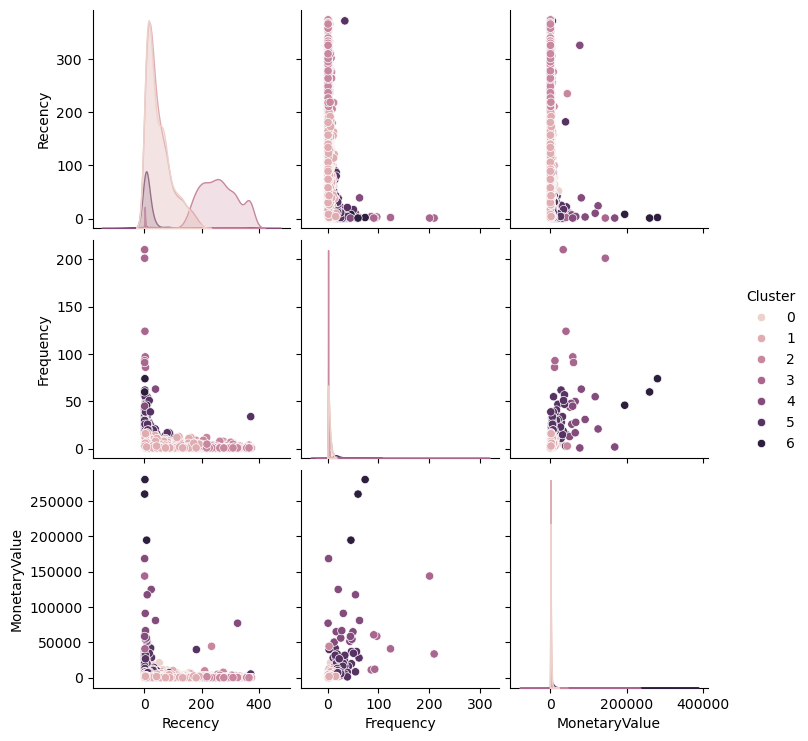

In [7]:
import seaborn as sns
sns.pairplot(rfm, hue='Cluster', vars=['Recency','Frequency','MonetaryValue'])

In [10]:
X = rfm[['Recency','Frequency','MonetaryValue','Cluster']]
X.to_csv("X_features.csv", index=False)